---
title: "How have player demographics changed over the history of the league?"
format:
  html:
    code-fold: true
    code-tools: true
    embed-resources: true
---

Here you will find my slightly more unedited and data-forward look at the data for this post. This won't be anything crazy, but perhaps a little more technical, a little more raw data and raw code. My overall design philosophy for this website is to be design and story forward on the front-end, but with more technical detail easily available for the folks who are so inclined. With that, let's look a bit more closely at the raw data.

## Nationality: From pure Canada to North American Mix

In [5]:
# ----------------------------------------------------------------------
#
# LIBRARIES
#
# ----------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl

# Font
mpl.rcParams['font.family'] = 'Charter'
print("Using font:", mpl.rcParams['font.family'])  # should say ['Charter']


# Hardcoded project root
PROJECT_ROOT = "/Users/dwiwad/dev/hockey_site"

Using font: ['Charter']


In [6]:
# ----------------------------------------------------------------------
#
# READ IN THE DATA
#
# ----------------------------------------------------------------------

roster = pd.read_csv("~/dev/hockey_site/data/nhl-player-demographics/rosters.csv")

# ----------------------------------------------------------------------
#
# ROSTER COUNTS
#
# ----------------------------------------------------------------------

print('Total number of NHL rostered players from 1917 to 2025:', len(roster))
print('Total roster years:', roster['season'].nunique())
print('Total unique rostered players from 1917 to 2025:', roster['id'].nunique())

Total number of NHL rostered players from 1917 to 2025: 55567
Total roster years: 107
Total unique rostered players from 1917 to 2025: 8595


In [7]:
# ----------------------------------------------------------------------
#
# NATIONALITY PROPORTIONS IN THE 2024-2025 AND OVERALL PLOT
#
# ----------------------------------------------------------------------

# Get the simple counts of country by season
country_year_df = roster.groupby(['season', 'birth_country']).size().reset_index(name='count')

# Add in total players per season
country_year_df['total_players'] = country_year_df.groupby('season')['count'].transform('sum')

# Add in proportions
country_year_df['country_prop'] = (country_year_df['count'] / country_year_df['total_players'])

# Split season into a nice labelled variable
def split_and_hyphenate(number):
    s_number = str(number)
    # Example: Split into first 3 and remaining digits
    part1 = s_number[:4]
    part2 = s_number[4:]
    return f"{part1}-{part2}"

# Apply the function to create a new column
country_year_df['season_label'] = country_year_df['season'].apply(split_and_hyphenate)

# Clean up the countries into groupings
def map_country_group(country):
    if country == 'CAN':
        return 'Canada'
    elif country == 'USA':
        return 'USA'
    elif country in ['SWE', 'FIN', 'NOR', 'DNK']:
        return 'Scandinavia'
    elif country in ['CZE', 'SVK']:
        return 'Central Europe'
    elif country in ['RUS', 'BLR', 'UKR', 'KAZ']:
        return 'Former USSR'
    elif country in ['DEU', 'AUT', 'SUI']:  # Germany, Austria, Switzerland
        return 'Western Europe'
    elif country in ['FRA', 'GBR', 'IRL', 'NLD', 'BEL']:
        return 'Other Europe'
    else:
        return 'Other'

# Apply dataframe dataframe
country_year_df['country_group'] = country_year_df['birth_country'].apply(map_country_group)

# ----------------------------------------------------------------------
# AGGREGATION FOR PLOTTING
# ----------------------------------------------------------------------

# Get the max season
latest_season = country_year_df['season'].max()

# Get the latest group totals
latest_group_totals = (
    country_year_df.query("season == @latest_season")
    .groupby('country_group', as_index=False)['country_prop']
    .sum()
)

latest_order = (
    latest_group_totals
    .sort_values('country_prop', ascending=False)['country_group']
    .tolist()
)

top_groups = latest_group_totals.nlargest(5, 'country_prop')['country_group'].tolist()

# aggregate to group-by-season before plotting 
plot_df = (
    country_year_df[country_year_df['country_group'].isin(top_groups)]
    .groupby(['season', 'country_group'], as_index=False)['country_prop']
    .sum()
)

# Re-add the season label
plot_df['season_label'] = plot_df['season'].apply(split_and_hyphenate)

# Convert to categorical to enforce order
plot_df['country_group'] = pd.Categorical(plot_df['country_group'], categories=top_groups, ordered=True)


### Plot the country trends

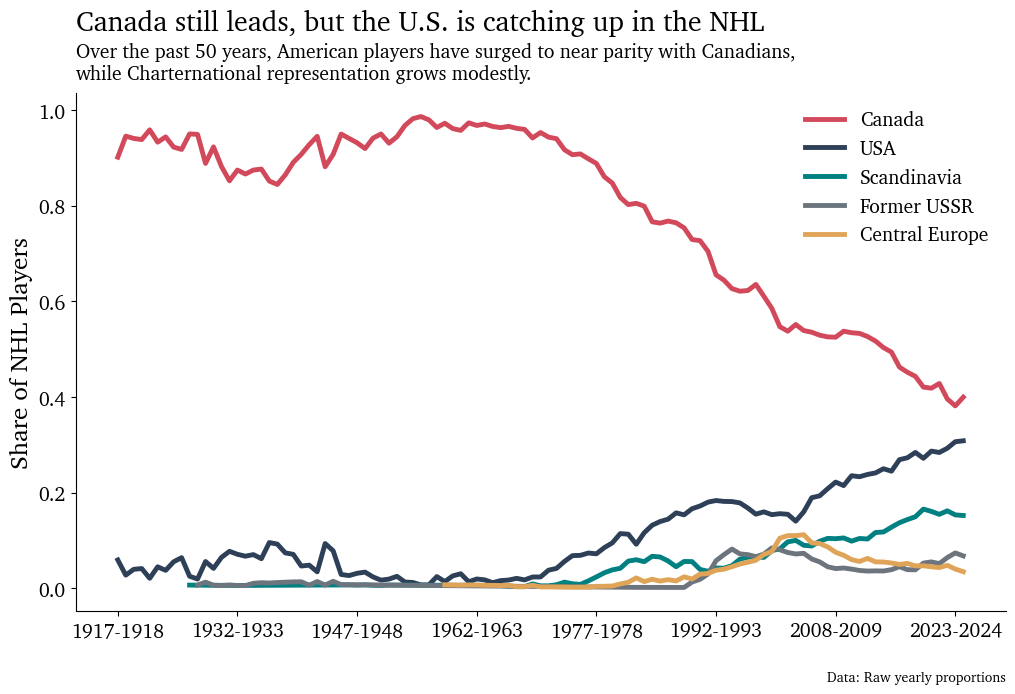

In [8]:
# ----------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=plot_df,
    x="season_label",
    y="country_prop",
    hue="country_group",
    palette={
        'Canada': '#D1495B',
        'USA': '#2E4057',
        'Scandinavia': '#008080',
        'Central Europe': '#E0A458',
        'Former USSR': '#6C757D'
    },
    linewidth=3.5,
    ax=ax,
    errorbar=None  
)

# Set a clean aesthetic style
mpl.rcParams['font.family'] = 'Charter'
sns.despine()
ax.grid(False)

# X-tick labels
# Get unique season labels every 15 steps
tick_labels = plot_df['season_label'].unique()[::15]

# Set ticks and labels using actual string values
ax.set_xticks(tick_labels)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Share of NHL Players", fontsize=18)

# Calculate left margin in figure coords
left_x = ax.get_position().x0

# Reserve more space at the top for the titles
plt.subplots_adjust(top=0.85)  # moves the plot down, freeing top 15% of figure height

# Title (main)
fig.suptitle(
    "Canada still leads, but the U.S. is catching up in the NHL",
    fontsize=20,
    weight='bold',
    x=left_x,
    ha='left',
    y=.97  # Top of reserved space
)

# Subtitle
fig.text(
    left_x,
    0.87,  # Slightly below the main title
    "Over the past 50 years, American players have surged to near parity with Canadians,\n"
    "while Charternational representation grows modestly.",
    fontsize=14,
    ha='left'
)

fig.text(
    0.9,
    0.01,
    "Data: Raw yearly proportions", 
    fontsize=10, 
    style='italic', 
    ha='right'
)

# Legend
ax.legend(title="", frameon=False, loc='upper right', fontsize=14)

plt.show()

## Deep Dive Final Age, Height, and Weight Figures

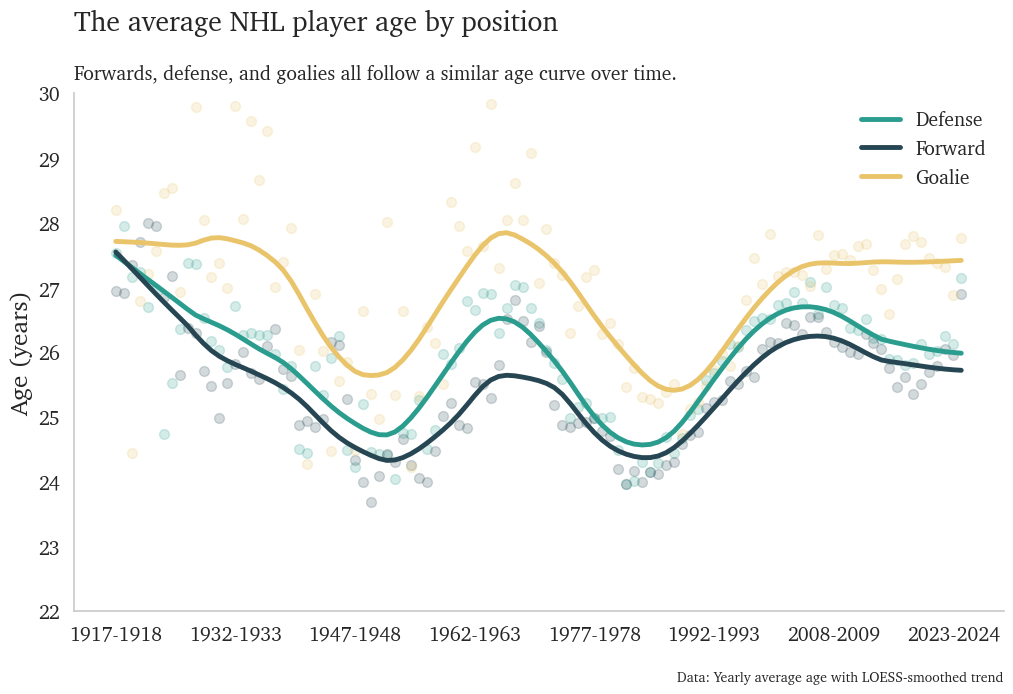

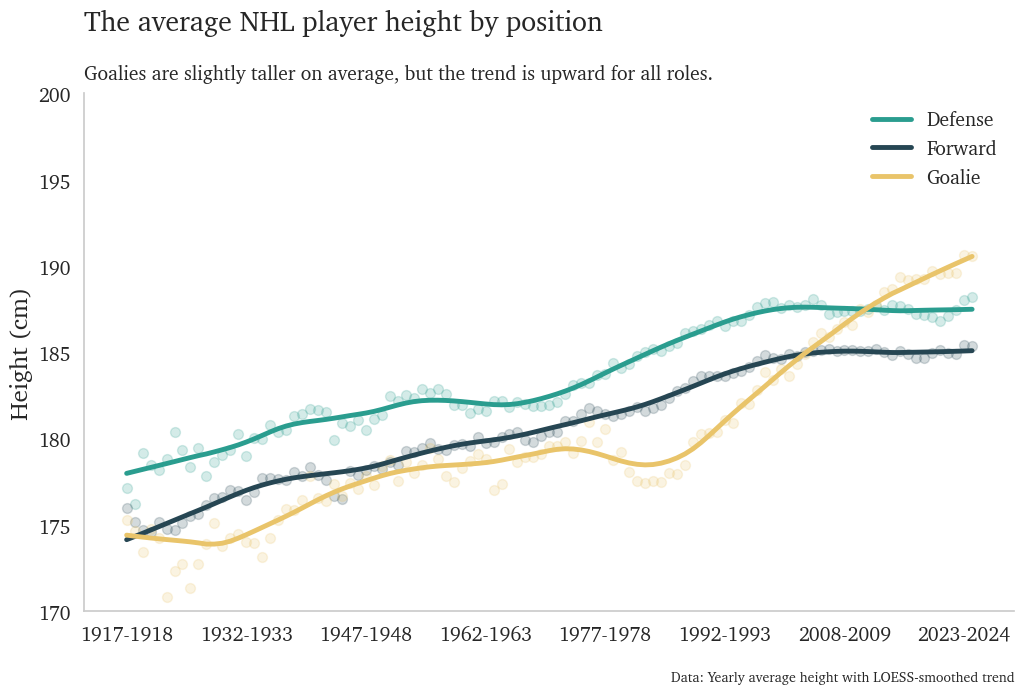

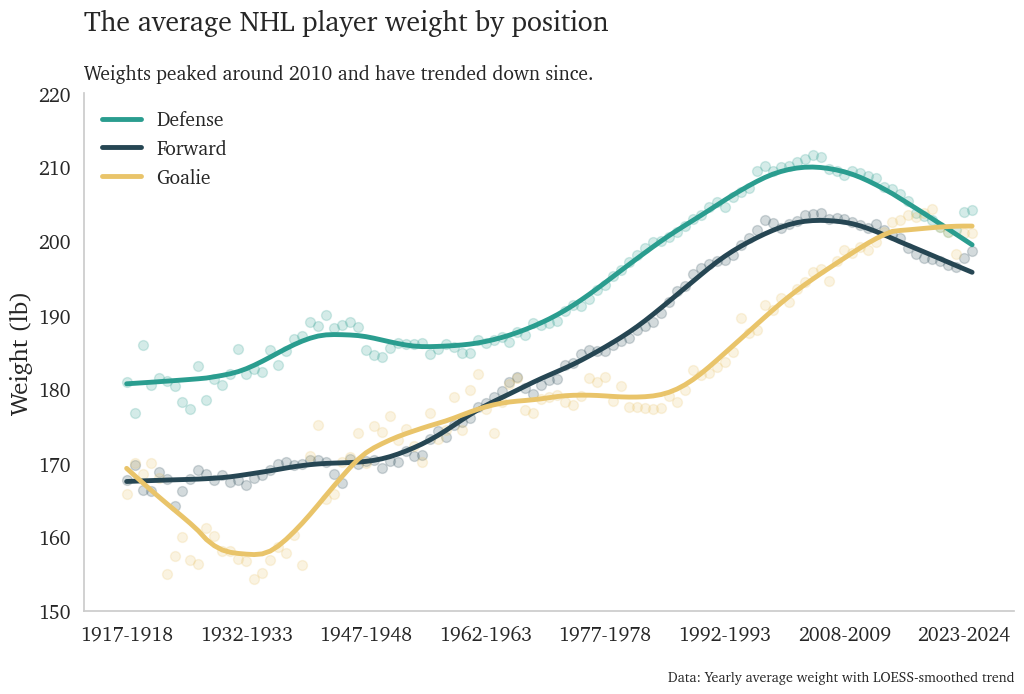

In [9]:
# ----------------------------------------------------------------------
#
# CLEAN AGE, HEIGHT, AND WEIGHT BY POSITION GROUP
#
# ----------------------------------------------------------------------

# Get roster size by year 
season_roster_size = roster.groupby('season')['id'].nunique()

# Map position to groups
position_map = {'C': 'Forward', 'R': 'Forward', 'L': 'Forward', 'D': 'Defense', 'G': 'Goalie'}
roster['position_group'] = roster['position'].map(position_map)

# Convert height to cm
roster['height_cm'] = roster['height_in'] * 2.54

# Format season label
def split_and_hyphenate(number):
    s_number = str(number)
    return f"{s_number[:4]}-{s_number[4:]}"


# Plotting function
def plot_clean_position_trend(df, value_col, ylabel, title, subtitle, filename, ylims, yticks, color_map):
    sns.set(style="whitegrid")
    mpl.rcParams['font.family'] = 'Charter'
    fig, ax = plt.subplots(figsize=(12, 7))

    for group in df['position_group'].unique():
        group_df = df[df['position_group'] == group]

        # Dots
        ax.scatter(
            group_df['x_pos'],
            group_df[value_col],
            color=color_map[group],
            alpha=0.2,
            s=50
        )

        # Smoothed LOESS line
        smoothed = lowess(
            endog=group_df[value_col],
            exog=group_df['x_pos'],
            frac=0.2,
            return_sorted=True
        )
        ax.plot(
            smoothed[:, 0],
            smoothed[:, 1],
            color=color_map[group],
            linewidth=3.5,
            label=group
        )

    ax.set_ylim(ylims)
    ax.set_yticks(yticks)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x))}"))
    sns.despine()
    ax.grid(False)

    tick_indices = list(range(0, len(season_labels), 15))
    tick_labels = [season_labels[i] for i in tick_indices]
    ax.set_xticks(tick_indices)
    ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_xlabel("")

    left_x = ax.get_position().x0
    plt.subplots_adjust(top=0.85)
    fig.suptitle(title, fontsize=20, weight='bold', x=left_x, ha='left', y=0.97)
    fig.text(left_x, 0.87, subtitle, fontsize=14, ha='left')
    clean_label = {"age": "age", "height_cm": "height", "weight_lb": "weight"}.get(value_col, value_col.split("_")[0])
    fig.text(0.9, 0.01, f"Data: Yearly average {clean_label} with LOESS-smoothed trend", 
             fontsize=10, style='italic', ha='right')
    legend_loc = 'upper left' if value_col == 'weight_lb' else 'upper right'
    ax.legend(title='', loc=legend_loc, frameon = False, fontsize = 14)
    plt.show()

# Loop for each variable
for varname, ylabel, title, subtitle, filename, ylims, yticks in [
    (
        'age',
        'Age (years)',
        'The average NHL player age by position',
        'Forwards, defense, and goalies all follow a similar age curve over time.',
        'nhl_age_by_position.png',
        (22, 30),
        range(22, 31)
    ),
    (
        'height_cm',
        'Height (cm)',
        'The average NHL player height by position',
        'Goalies are slightly taller on average, but the trend is upward for all roles.',
        'nhl_height_by_position.png',
        (170, 200),
        range(170, 201, 5)
    ),
    (
        'weight_lb',
        'Weight (lb)',
        'The average NHL player weight by position',
        'Weights peaked around 2010 and have trended down since.',
        'nhl_weight_by_position.png',
        (150, 220),                # <-- y-axis limits
        range(150, 221, 10)        # <-- y-axis ticks
    )
]:
    temp_df = roster.dropna(subset=['season', 'birth_date', 'position_group']).copy()
    temp_df['birth_date'] = pd.to_datetime(temp_df['birth_date'])
    temp_df['reference_date'] = pd.to_datetime(temp_df['season'].astype(str).str[:4] + '-01-01')

    if varname == 'age':
        temp_df['value'] = (temp_df['reference_date'] - temp_df['birth_date']).dt.days / 365.25
    else:
        temp_df['value'] = temp_df[varname]

    temp_df['season_label'] = temp_df['season'].apply(split_and_hyphenate)

    avg_df = (
        temp_df.groupby(['season_label', 'position_group'])['value']
        .mean()
        .reset_index()
        .rename(columns={'value': varname})
    )

    season_labels = avg_df['season_label'].unique()
    season_to_index = {label: i for i, label in enumerate(season_labels)}
    avg_df['x_pos'] = avg_df['season_label'].map(season_to_index)

    color_map = {
        'Forward': '#264653',
        'Defense': '#2a9d8f',
        'Goalie': '#e9c46a'
    }

    plot_clean_position_trend(
        df=avg_df,
        value_col=varname,
        ylabel=ylabel,
        title=title,
        subtitle=subtitle,
        filename=filename,
        ylims=ylims,
        yticks=yticks,
        color_map=color_map
    )


## More Raw Data

Okay, I just want to include some slightly more raw data into this markdown doc. First, I just want to visualize age, height, and weight raw. This could probably be a little tighter and function-ized like the code above but I just don't have that kind of energy right now so here it is.

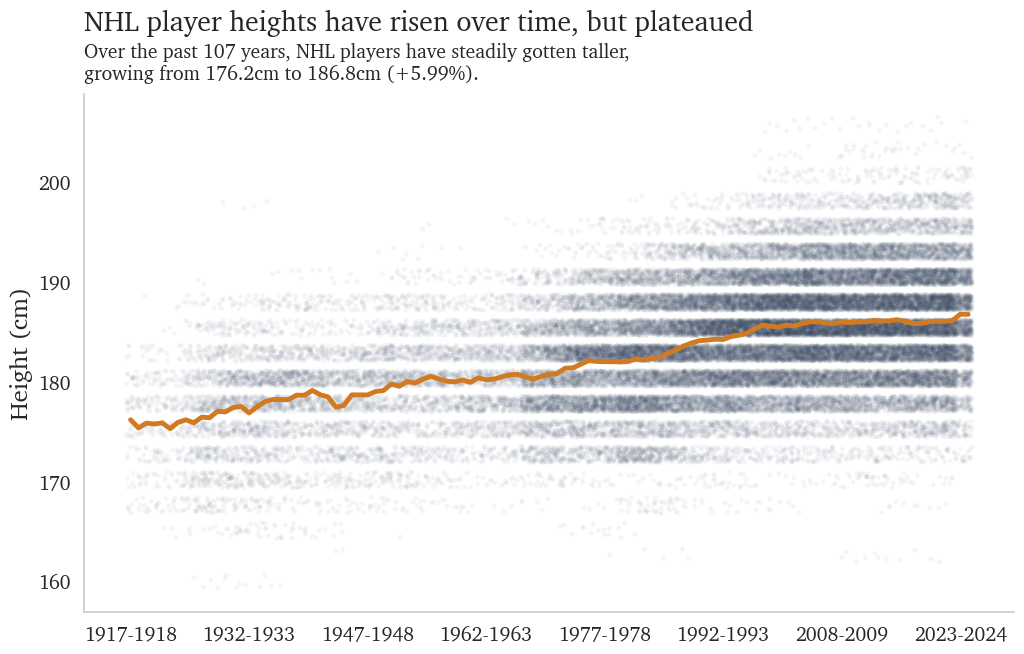

In [12]:
# Clean up data and convert height to cm
height_df = roster[['season', 'height_in']].dropna().copy()
height_df['height_cm'] = height_df['height_in'] * 2.54
height_df['season_label'] = height_df['season'].apply(split_and_hyphenate)

# Create jittered data
np.random.seed(42)
jittered_x = np.arange(len(height_df)) + np.random.uniform(-0.5, 0.5, size=len(height_df))
jittered_y = height_df['height_cm'] + np.random.uniform(-0.8, 0.8, size=len(height_df))

# Map seasons to numeric x values
season_labels = height_df['season_label'].unique()
season_to_index = {label: i for i, label in enumerate(season_labels)}
height_df['x_pos'] = height_df['season_label'].map(season_to_index)

# Compute average height by season
avg_height = (
    height_df.groupby('season_label')['height_cm']
    .mean()
    .reset_index()
)
avg_height['x_pos'] = avg_height['season_label'].map(season_to_index)

# PLOT
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: faded, jittered dots
ax.scatter(
    height_df['x_pos'] + np.random.uniform(-0.5, 0.5, size=len(height_df)),
    height_df['height_cm'] + np.random.uniform(-0.8, 0.8, size=len(height_df)),
    alpha=0.05,
    color='#3B4B64',
    edgecolor='none',
    s=12
)

# Line: average height per season
sns.lineplot(
    data=avg_height,
    x="x_pos",
    y="height_cm",
    ax=ax,
    color='#D17A22',
    linewidth=3.5,
    zorder=10
)

# Style
sns.despine()
ax.grid(False)

# X-axis ticks and labels
tick_indices = list(range(0, len(season_labels), 15))
tick_labels = [season_labels[i] for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)

# Y-axis tick label styling
ax.tick_params(axis='y', labelsize=14)

# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Height (cm)", fontsize=18)

# Layout and title position
left_x = ax.get_position().x0
plt.subplots_adjust(top=0.85)

# Title
fig.suptitle(
    "NHL player heights have risen over time, but plateaued",
    fontsize=20,
    weight='bold',
    x=left_x,
    ha='left',
    y=0.97
)

# Subtitle
fig.text(
    left_x,
    0.87,
    "Over the past 107 years, NHL players have steadily gotten taller,\ngrowing from 176.2cm to 186.8cm (+5.99%).",
    fontsize=14,
    ha='left'
)

# Show
plt.show()

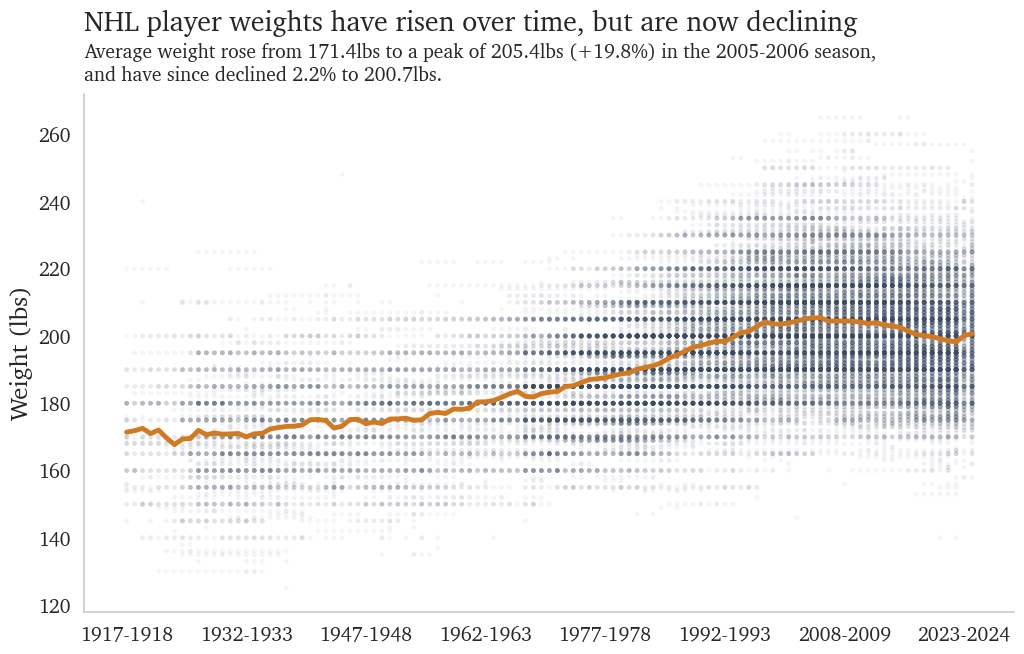

In [20]:
# Clean up data
weight_df = roster[['season', 'weight_lb']].dropna().copy()
weight_df['season_label'] = weight_df['season'].apply(split_and_hyphenate)

# Map seasons to numeric x values
season_labels = weight_df['season_label'].unique()
season_to_index = {label: i for i, label in enumerate(season_labels)}
weight_df['x_pos'] = weight_df['season_label'].map(season_to_index)

# Compute average height by season
avg_weight = (
    weight_df.groupby('season_label')['weight_lb']
    .mean()
    .reset_index()
)
avg_weight['x_pos'] = avg_weight['season_label'].map(season_to_index)

# PLOT
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: faded, jittered dots
ax.scatter(
    weight_df['x_pos'],
    weight_df['weight_lb'],
    alpha=0.05,
    color='#3B4B64',
    edgecolor='none',
    s=12
)

# Line: average height per season
sns.lineplot(
    data=avg_weight,
    x="x_pos",
    y="weight_lb",
    color='#D17A22',
    linewidth=3.5,
    zorder=10
)

# Style
sns.despine()
ax.grid(False)

# X-axis ticks and labels
tick_indices = list(range(0, len(season_labels), 15))
tick_labels = [season_labels[i] for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)

# Y-axis tick label styling
ax.tick_params(axis='y', labelsize=14)

# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Weight (lbs)", fontsize=18)

# Layout and title position
left_x = ax.get_position().x0
plt.subplots_adjust(top=0.85)

# Title
fig.suptitle(
    "NHL player weights have risen over time, but are now declining",
    fontsize=20,
    weight='bold',
    x=left_x,
    ha='left',
    y=0.97
)

# Subtitle
fig.text(
    left_x,
    0.87,
    "Average weight rose from 171.4lbs to a peak of 205.4lbs (+19.8%) in the 2005-2006 season,\nand have since declined 2.2% to 200.7lbs.",
    fontsize=14,
    ha='left'
)

# Show
plt.show()

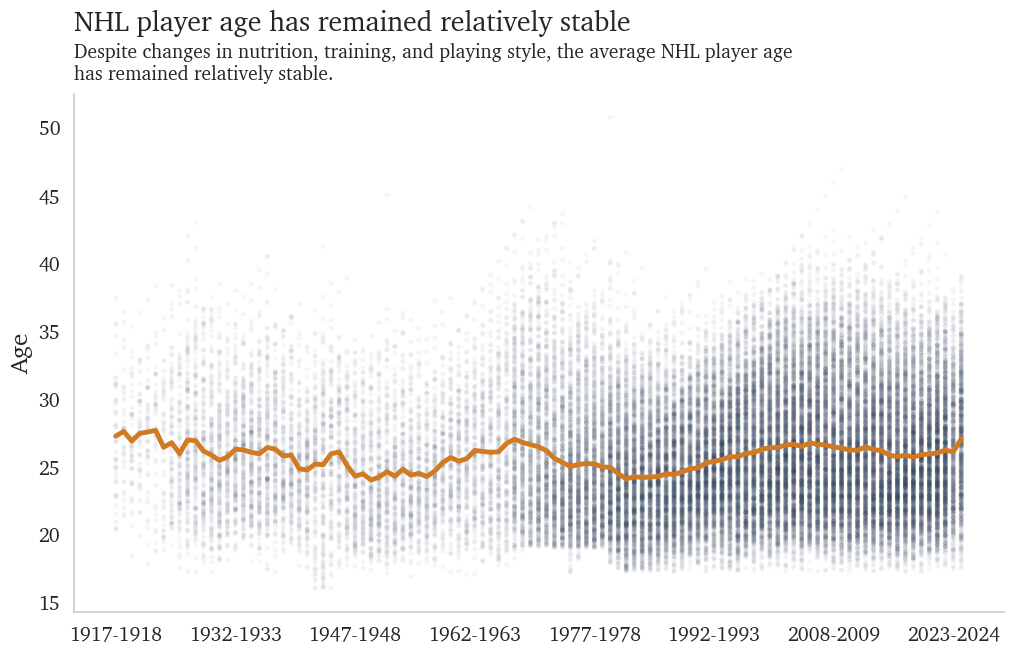

In [23]:
# Clean and calculate age
age_df = roster[['season', 'birth_date']].dropna().copy()
age_df['birth_date'] = pd.to_datetime(age_df['birth_date'])

# Assume players are measured at January 1st of each season year
age_df['reference_date'] = pd.to_datetime(age_df['season'].astype(str).str[:4] + '-01-01')
age_df['age'] = (age_df['reference_date'] - age_df['birth_date']).dt.days / 365.25

# Format season label and assign x-axis numeric positions
age_df['season_label'] = age_df['season'].apply(split_and_hyphenate)
season_labels = age_df['season_label'].unique()
season_to_index = {label: i for i, label in enumerate(season_labels)}
age_df['x_pos'] = age_df['season_label'].map(season_to_index)


# Map seasons to numeric x values
season_labels = age_df['season_label'].unique()
season_to_index = {label: i for i, label in enumerate(season_labels)}
age_df['x_pos'] = age_df['season_label'].map(season_to_index)

# Compute average height by season
avg_age = (
    age_df.groupby('season_label')['age']
    .mean()
    .reset_index()
)
avg_age['x_pos'] = avg_age['season_label'].map(season_to_index)

# PLOT
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: faded, jittered dots
ax.scatter(
    age_df['x_pos'],
    age_df['age'],
    alpha=0.05,
    color='#3B4B64',
    edgecolor='none',
    s=12
)

# Line: average height per season
sns.lineplot(
    data=avg_age,
    x="x_pos",
    y="age",
    color='#D17A22',
    linewidth=3.5,
    zorder=10
)

# Style
sns.despine()
ax.grid(False)

# X-axis ticks and labels
tick_indices = list(range(0, len(season_labels), 15))
tick_labels = [season_labels[i] for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)

# Y-axis tick label styling
ax.tick_params(axis='y', labelsize=14)

# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Age", fontsize=18)

# Layout and title position
left_x = ax.get_position().x0
plt.subplots_adjust(top=0.85)

# Title
fig.suptitle(
    "NHL player age has remained relatively stable",
    fontsize=20,
    weight='bold',
    x=left_x,
    ha='left',
    y=0.97
)

# Subtitle
fig.text(
    left_x,
    0.87,
    "Despite changes in nutrition, training, and playing style, the average NHL player age\nhas remained relatively stable.",
    fontsize=14,
    ha='left'
)

# Show
plt.show()

## Testing a hypothesis: Roster Turnover

As noted in the deep dive section about age trends, I'm curious if there is less roster turnover in years where the league was not expanding. This would provide some credence to the idea that when the league is expanding more players are coming in from the bottom and thus the average age declines, whereas in periods of league stagnation, less players come in from the bottom and thus the league just ages.

I'm going to test this by visualizing league roster turnover year over year (e.g., for a given year, how many ids are the same as the year previous). We should see that in expansion periods have less ids that were present in the previous year.

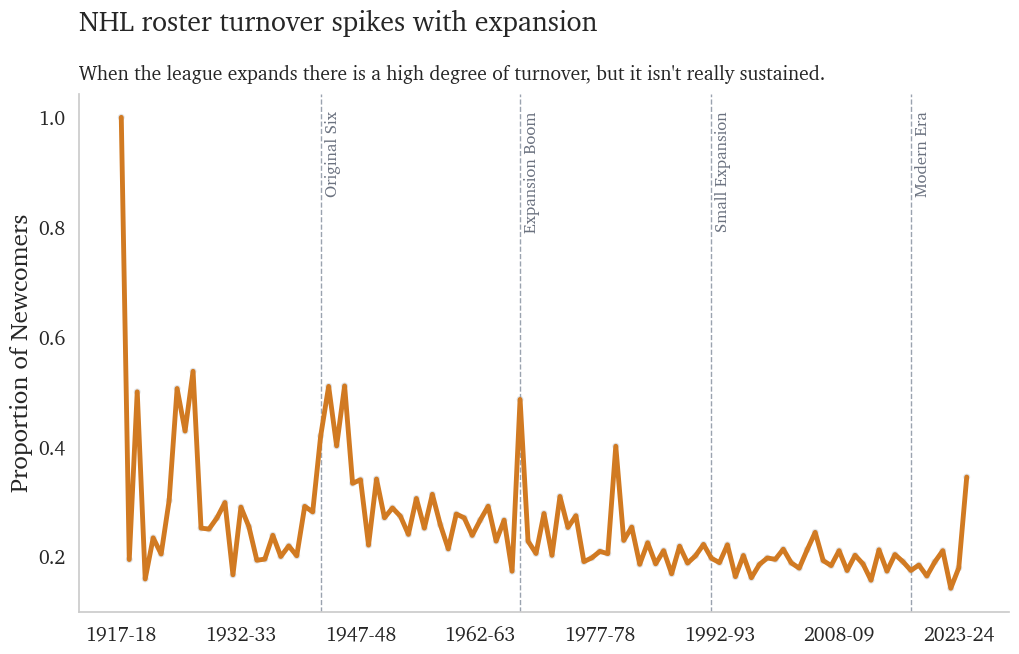

In [41]:
# 0) Clean, de-dup per player-season
id_df = (
    roster[['season', 'id']]
    .dropna()
    .drop_duplicates()           # ensure one row per id-season
    .copy()
)

def season_start(season):
    s = str(season)
    return int(s[:4])

def season_label(season):
    s = str(season)
    return f"{s[:4]}-{s[4:]}"

id_df['season_start'] = id_df['season'].apply(season_start)
id_df['season_label'] = id_df['season'].apply(season_label)

# 1) Build an ordered list of actual seasons in your data
seasons_sorted = sorted(id_df['season_start'].unique())

# Map each season to the *previous real season* (skip gaps like 2004-05)
prev_map = {s: p for s, p in zip(seasons_sorted[1:], seasons_sorted[:-1])}

# 2) Build a set of (id, season_start) pairs and flag returning players
pairs = set(zip(id_df['id'], id_df['season_start']))

id_df['in_prev_season'] = id_df.apply(
    lambda r: int((r['id'], prev_map.get(r['season_start'], None)) in pairs)
              if prev_map.get(r['season_start'], None) is not None else 0,
    axis=1
)

# 3) Compute per-season turnover = share of newcomers
season_turnover = (
    id_df
      .groupby('season_start', as_index=False)
      .agg(
          players_this_season=('id', 'nunique'),
          returning=('in_prev_season', 'sum')
      )
)
season_turnover['newcomers'] = season_turnover['players_this_season'] - season_turnover['returning']
season_turnover['turnover_rate'] = season_turnover['newcomers'] / season_turnover['players_this_season']

# 4) Add your era buckets (rename Modern end as you like)
def era_of(y):
    if y < 1942: return 'Early Era (≤1941)'
    if y < 1967: return 'Original Six (1942–1966)'
    if y < 1991: return 'Expansion Boom (1967–1990)'
    if y < 2017: return 'Expansion II (1991–2016)'
    return 'Modern Era (2017–present)'

season_turnover['era'] = season_turnover['season_start'].apply(era_of)

# 5) Optional: compare to “expansion pressure”
#    Use total player count (or #teams if you have it) and look at year-over-year change
season_turnover = season_turnover.sort_values('season_start')
season_turnover['delta_players'] = season_turnover['players_this_season'].diff()

# Example summaries:
era_summary = (season_turnover
               .groupby('era', as_index=False)['turnover_rate']
               .mean()
               .rename(columns={'turnover_rate': 'avg_turnover_rate'}))

# Quick check: overall newcomer share (what your mean() was aiming at)
overall_turnover = 1 - id_df['in_prev_season'].mean()


# --- PREPARE TURNOVER DATAFRAME (season_turnover) ---
# season_turnover should already have: season_start, turnover_rate

# Build season labels (e.g., 1917-18, 1918-19, ...)
season_turnover['season_label'] = season_turnover['season_start'].astype(str) + '-' + (season_turnover['season_start']+1).astype(str).str[-2:]

# Map seasons to numeric x positions
season_labels = season_turnover['season_label'].unique()
season_to_index = {label: i for i, label in enumerate(season_labels)}
season_turnover['x_pos'] = season_turnover['season_label'].map(season_to_index)

# --- PLOT ---
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: faded dots for season-level turnover
ax.scatter(
    season_turnover['x_pos'],
    season_turnover['turnover_rate'],
    alpha=0.15,
    color='#3B4B64',
    edgecolor='none',
    s=25
)

# Line: average turnover per season
sns.lineplot(
    data=season_turnover,
    x="x_pos",
    y="turnover_rate",
    color='#D17A22',
    linewidth=3.5,
    zorder=10
)

# >>> Era start vertical lines + labels <<<
era_starts = {
    1942: "Original Six",
    1967: "Expansion Boom",
    1991: "Small Expansion",
    2017: "Modern Era"
}
# Add lines only if those seasons exist in your data
ymax = ax.get_ylim()[1]
for year, label in era_starts.items():
    era_label = f"{year}-{str(year+1)[-2:]}"
    if era_label in season_to_index:
        xpos = season_to_index[era_label]
        ax.axvline(x=xpos, color='#9AA3AF', linestyle='--', linewidth=1)
        ax.text(
            xpos + 0.5, ymax * 0.97, label,
            rotation=90, va='top', ha='left',
            fontsize=12, color='#6B7280'
        )

# Style
sns.despine()
ax.grid(False)

# X-axis ticks and labels
tick_indices = list(range(0, len(season_labels), 15))
tick_labels = [season_labels[i] for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)

# Y-axis tick label styling
ax.tick_params(axis='y', labelsize=14)

# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Proportion of Newcomers", fontsize=18)

# Layout and title position
left_x = ax.get_position().x0
plt.subplots_adjust(top=0.85)

# Title
fig.suptitle(
    "NHL roster turnover spikes with expansion",
    fontsize=20,
    weight='bold',
    x=left_x,
    ha='left',
    y=0.97
)

# Subtitle
fig.text(
    left_x,
    0.87,
    "When the league expands there is a high degree of turnover, but it isn't really sustained.",
    fontsize=14,
    ha='left'
)

plt.show()

So, I'm not really convinced that this is the explanation, as we would expect to see sharper drops in average age if this was causing it. I think we do see an overall trend where there is more turnover in expansion eras. What does the era turnover look like?

In [42]:
era_order = [
    "Early Era (≤1941)",
    "Original Six (1942–1966)",
    "Expansion Boom (1967–1990)",
    "Expansion II (1991–2016)",
    "Modern Era (2017–present)",
]
season_turnover['era'] = pd.Categorical(season_turnover['era'], categories=era_order, ordered=True)

# 2) Precompute weighted term (turnover * players)
season_turnover['wt_turnover'] = season_turnover['turnover_rate'] * season_turnover['players_this_season']

# 3) Weighted average without .apply (no deprecation warning)
era_turnover = (
    season_turnover
    .groupby('era', observed=True)
    .agg(
        weighted_sum=('wt_turnover', 'sum'),
        total_players=('players_this_season', 'sum'),
        avg_players=('players_this_season', 'mean')
    )
    .assign(weighted_turnover_rate=lambda d: d['weighted_sum'] / d['total_players'])
    .reset_index()
    .sort_values('era')  # respects the categorical order above
    .loc[:, ['era', 'weighted_turnover_rate', 'avg_players']]
)

era_turnover


,era,weighted_turnover_rate,avg_players
0,Early Era (≤1941),0.282185,123.040000
1,Original Six (1942–1966),0.297207,156.120000
2,Expansion Boom (1967–1990),0.232385,561.208333
3,Expansion II (1991–2016),0.193761,927.120000
4,Modern Era (2017–present),0.196936,954.625000


So we basically are just seeing an overall decline in roster turnover. So this is interesting but I don't think helps explain the age trend!